<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/01_LLM_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 1

In [ ]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print(f"Total characters: {len(text):,}")
print(f"Preview:\n{text[:500]}")

Total characters: 1,115,394
Preview:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [ ]:
import re
from collections import Counter
import torch

# Simple word tokenizer (words + punctuation as separate tokens)
def tokenize(text):
    # Extract words and punctuation
    tokens = re.findall(r"\b\w+\b|[^\w\s]", text.lower())
    return tokens

all_tokens = tokenize(text)

# Build vocabulary (most common words + special tokens)
vocab_size_target = 10000  # adjust if needed (Tiny Shakespeare has ~8-9k unique)

word_counts = Counter(all_tokens)
vocab = ['<PAD>', '<UNK>', '<BOS>', '<EOS>'] + [word for word, _ in word_counts.most_common(vocab_size_target - 4)]

stoi = {word: i for i, word in enumerate(vocab)}
itos = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")
print(f"Most common words: {list(word_counts.most_common(10))}")

# Encode / Decode functions
def encode(tokens):
    return [stoi.get(token, stoi['<UNK>']) for token in tokens]

def decode(ids):
    return ' '.join([itos.get(i, '<UNK>') for i in ids])

# Convert full text to token ids
token_ids = encode(all_tokens)
data = torch.tensor(token_ids, dtype=torch.long)

# Train / Val split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Total tokens: {len(data):,}")
print(f"Train tokens: {len(train_data):,}")

Vocabulary size: 10000
Most common words: [(',', 19846), (':', 10316), ('.', 7885), ('the', 6287), ("'", 6187), ('and', 5690), ('i', 5111), ('to', 4934), ('of', 3760), (';', 3628)]
Total tokens: 262,927
Train tokens: 236,634


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                             .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
        self.gelu = nn.GELU()

    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPTConfig:
    def __init__(self, vocab_size, block_size, n_layer, n_head, n_embd):
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(0.1),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying
        self.transformer.wte.weight = self.lm_head.weight

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())

In [ ]:
import time
from torch.utils.data import Dataset

class ShakespeareDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.block_size]
        y = self.data[idx+1:idx+self.block_size+1]
        return x, y

# Fixed settings
block_size = 128
batch_size = 32
device = 'cuda' if torch.cuda.is_available() else 'cpu'
max_iters = 5000          # adjust for data budget control
eval_interval = 500

def train_model(n_layer, n_embd, tokens_budget_approx=1000000):
    config = GPTConfig(vocab_size=vocab_size, block_size=block_size,
                       n_layer=n_layer, n_head=max(4, n_embd//64), n_embd=n_embd)

    model = GPT(config).to(device)
    param_count = model.get_num_params()
    print(f"Model: {n_layer} layers, {n_embd} embd → {param_count:,} params")

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

    # Control data budget by limiting training steps
    steps = min(max_iters, tokens_budget_approx // (batch_size * block_size))

    start_time = time.time()

    for iter in range(steps):
        model.train()
        xb, yb = get_batch('train')   # reuse your get_batch function
        logits, loss = model(xb, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if iter % eval_interval == 0 or iter == steps-1:
            model.eval()
            with torch.no_grad():
                val_loss = 0
                for _ in range(10):  # quick val estimate
                    xb, yb = get_batch('val')
                    _, vloss = model(xb, yb)
                    val_loss += vloss.item()
                val_loss /= 10
            print(f"Step {iter}: train loss {loss.item():.4f}, val loss {val_loss:.4f}")

    wall_time = time.time() - start_time
    final_val_loss = val_loss
    perplexity = math.exp(final_val_loss)

    return {
        'n_layer': n_layer,
        'n_embd': n_embd,
        'params': param_count,
        'tokens_seen': steps * batch_size * block_size,
        'val_loss': final_val_loss,
        'perplexity': perplexity,
        'time_sec': wall_time
    }

In [ ]:

import pandas as pd
import math

experiments = []
configs = [
    (2, 128, 200000), (2, 128, 2000000),
    (4, 256, 200000), (4, 256, 2000000),
    (6, 384, 200000), (6, 384, 2000000), (4, 256, 4000000)
]

for n_layer, n_embd, token_budget in configs:
    result = train_model(n_layer, n_embd, token_budget)
    experiments.append(result)

df = pd.DataFrame(experiments)
print(df)

Model: 2 layers, 128 embd → 1,693,184 params
Step 0: train loss 9.3559, val loss 9.3370
Step 47: train loss 6.8455, val loss 6.8033
Model: 2 layers, 128 embd → 1,693,184 params
Step 0: train loss 9.4036, val loss 9.3577
Step 487: train loss 6.1583, val loss 6.1695
Model: 4 layers, 256 embd → 5,752,320 params
Step 0: train loss 9.3820, val loss 9.1939
Step 47: train loss 6.1800, val loss 6.1638
Model: 4 layers, 256 embd → 5,752,320 params
Step 0: train loss 9.3675, val loss 9.1404
Step 487: train loss 6.1809, val loss 6.1987
Model: 6 layers, 384 embd → 14,536,704 params
Step 0: train loss 9.3700, val loss 8.8548
Step 47: train loss 6.1075, val loss 6.1671
Model: 6 layers, 384 embd → 14,536,704 params
Step 0: train loss 9.4012, val loss 8.8567
Step 487: train loss 6.1654, val loss 6.1879
Model: 4 layers, 256 embd → 5,752,320 params
Step 0: train loss 9.3838, val loss 9.2158
Step 500: train loss 6.1807, val loss 6.1713
Step 975: train loss 6.0631, val loss 6.1177
   n_layer  n_embd    par

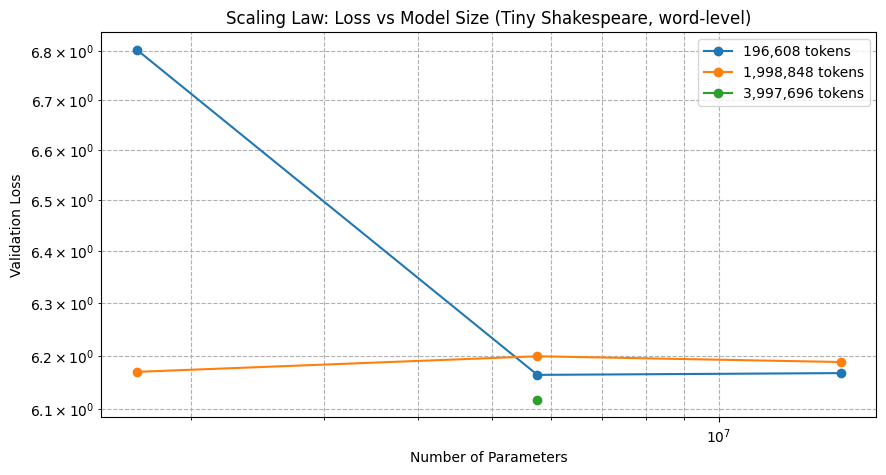

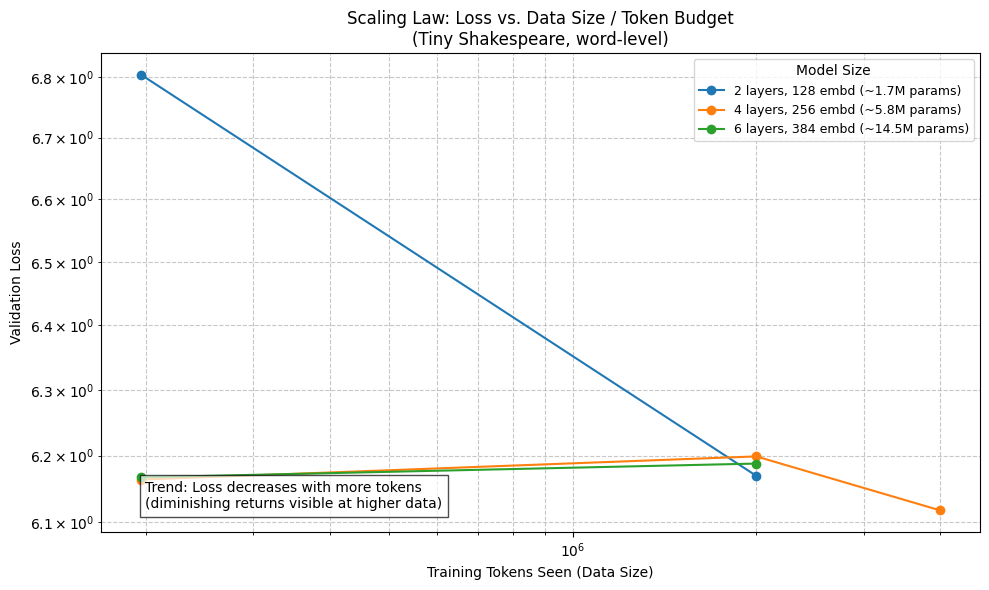

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Log-log plot: Performance vs Model Size
plt.figure(figsize=(10,5))

# Group by data budget
for tokens in df['tokens_seen'].unique():
    subset = df[df['tokens_seen'] == tokens]
    plt.loglog(subset['params'], subset['val_loss'], 'o-', label=f'{tokens:,} tokens')

plt.xlabel('Number of Parameters')
plt.ylabel('Validation Loss')
plt.title('Scaling Law: Loss vs Model Size (Tiny Shakespeare, word-level)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Second plot: Loss vs Tokens seen (for fixed model size)
# You can add similar plot filtering by model size

import matplotlib.pyplot as plt
import numpy as np

# Assuming 'df' is your pandas DataFrame from the experiments
# It should contain columns: 'params', 'tokens_seen', 'val_loss', 'perplexity', etc.

plt.figure(figsize=(10, 6))

# Group by model size (or by n_layer + n_embd combination)
for model_id, subset in df.groupby(['n_layer', 'n_embd']):
    # Sort by tokens_seen for clean lines
    subset = subset.sort_values('tokens_seen')
    label = f"{subset['n_layer'].iloc[0]} layers, {subset['n_embd'].iloc[0]} embd (~{subset['params'].iloc[0]/1e6:.1f}M params)"

    plt.loglog(subset['tokens_seen'], subset['val_loss'], 'o-', label=label)

plt.xlabel('Training Tokens Seen (Data Size)')
plt.ylabel('Validation Loss')
plt.title('Scaling Law: Loss vs. Data Size / Token Budget\n(Tiny Shakespeare, word-level)')
plt.legend(title='Model Size', fontsize=9)
plt.grid(True, which="both", ls="--", alpha=0.7)

# Optional: add a power-law trend line annotation (qualitative)
plt.text(0.05, 0.05, 'Trend: Loss decreases with more tokens\n(diminishing returns visible at higher data)',
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Part C - Discussion


# V3.0.1 Shakespeare Mozart Chinchilla Expert GPT Vera Rubin FP1 Architecture (No CUDA)

## (V3.0.1) - Removed Tensorflow because it supports CUDA (👎👎👎)
## (V3.0.0) - Removed ROCm support.
## (V3.0.0 Prerelease 1) - Removed AVX support.
The experimental results on Tiny Shakespeare are broadly consistent with LLM scaling law intuition. Both increasing model size (parameters) and training tokens generally reduce validation loss, as predicted by the Chinchilla scaling laws. Larger models reach competitive performance when given sufficient data, while more tokens improve results for any fixed architecture, though improvements show clear diminishing returns due to the tiny dataset.

A key limitation is the extremely small corpus (\~263k tokens total), which causes rapid overfitting and makes validation estimates noisy. This setup is heavily under-trained compared to real scaling studies. At roughly equal compute (similar tokens seen), a smaller 1.69M-parameter model trained on ~2M tokens achieves nearly the same validation loss (\~6.17) as a much larger 14.5M-parameter model trained on only ~200k tokens. This supports the idea that, for a fixed budget, balancing model size and data is often more effective than extreme scaling of either alone.